# 🎯 Lorentzian KNN — Breakout Entry Validation

Validates whether a **Lorentzian KNN classifier** can predict whether a breakout entry succeeds
within the first **10 trading days** after entry.

## Label definition
```
Y_breakout = 1  if  MFE_10d > |MAE_10d|   (favorable 10d move > adverse 10d move)
Y_breakout = 0  otherwise                  (price went more against us than for us)
```
- **MFE_10d** — max favorable excursion over 10 trading days after entry
- **MAE_10d** — max adverse excursion (stored negative) over same window

## Forked from train_models_001
- Same 55-feature set (`feature_columns.json`)
- Same chronological train/test split + purged embargo CV
- Same López de Prado sample uniqueness weights
- **Model**: Lorentzian KNN (`d = Σ log(1 + |Δfᵢ|)`) with isotonic calibration

**Prerequisites**: run `feature_pipeline_001.ipynb` → `all_trades_with_features.h5`

# 1. Setup

In [ ]:
import sys, os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, brier_score_loss,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# 2. Load Data

In [2]:
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')
training_df['entry_date'] = pd.to_datetime(training_df['entry_date'])
training_df['exit_date']  = pd.to_datetime(training_df['exit_date'])
training_df = training_df.sort_values('entry_date').reset_index(drop=True)

with open('feature_columns.json') as f:
    feature_columns = json.load(f)
feature_columns = [c for c in feature_columns if c in training_df.columns]

with pd.HDFStore('stocks_data_latest.h5', mode='r') as _store:
    close_px = _store['stocks']['close']
close_px.index = pd.to_datetime(close_px.index)

print(f'Trades loaded  : {len(training_df):,}')
print(f'Date range     : {training_df["entry_date"].min().date()} → {training_df["entry_date"].max().date()}')
print(f'Win rate (001) : {training_df["Y"].mean():.2%}')
print(f'Feature count  : {len(feature_columns)}')
print(f'Stocks panel   : {close_px.shape}')

Trades loaded  : 13,924
Date range     : 2017-05-22 → 2026-04-06
Win rate (001) : 38.30%
Feature count  : 55
Stocks panel   : (2500, 197)


# 3. Compute 10-Day MAE / MFE

Walk the daily close path from `entry_date` for exactly **10 trading days** and record:
- **MFE_10d** = `max(r)` — best unrealized gain
- **MAE_10d** = `min(r)` — worst unrealized loss (negative)

In [3]:
WINDOW_DAYS = 10


def compute_10d_mfe_mae(
    df: pd.DataFrame,
    close: pd.DataFrame,
    window: int = WINDOW_DAYS,
) -> pd.DataFrame:
    mfe_list, mae_list, dur_list = [], [], []

    for _, t in df.iterrows():
        sym = t['symbol']
        t0  = t['entry_date']

        if sym not in close.columns:
            mfe_list.append(np.nan); mae_list.append(np.nan); dur_list.append(np.nan)
            continue

        sym_close = close[sym].dropna()
        loc  = sym_close.index.searchsorted(t0)
        path = sym_close.iloc[loc : loc + window + 1]

        if len(path) < 2:
            mfe_list.append(np.nan); mae_list.append(np.nan); dur_list.append(np.nan)
            continue

        r = path / path.iloc[0] - 1
        mfe_list.append(float(r.max()))
        mae_list.append(float(r.min()))   # negative
        dur_list.append(len(path) - 1)

    out = df.copy()
    out['mfe_10d'] = mfe_list
    out['mae_10d'] = mae_list
    out['dur_10d'] = dur_list
    return out


print(f'Computing 10-day MFE/MAE for {len(training_df):,} trades …')
training_df = compute_10d_mfe_mae(training_df, close_px, window=WINDOW_DAYS)

n_before = len(training_df)
training_df = training_df.dropna(subset=['mfe_10d', 'mae_10d']).reset_index(drop=True)
print(f'Dropped  : {n_before - len(training_df)} (no price data)')
print(f'Remaining: {len(training_df):,}')
print(training_df[['mfe_10d', 'mae_10d', 'dur_10d']].describe().round(4))

Computing 10-day MFE/MAE for 13,924 trades …
Dropped  : 0 (no price data)
Remaining: 13,924
          mfe_10d     mae_10d     dur_10d
count  13924.0000  13924.0000  13924.0000
mean       0.0535     -0.0418      9.9999
std        0.0702      0.0521      0.0085
min        0.0000     -0.4388      9.0000
25%        0.0046     -0.0583     10.0000
50%        0.0320     -0.0251     10.0000
75%        0.0735     -0.0040     10.0000
max        0.9478      0.0000     10.0000


# 4. Build Breakout-Success Label

`Y_breakout = 1` if `MFE_10d > |MAE_10d|` — the favorable excursion dominated the adverse,
confirming the breakout had holding power in the first 10 days.

Breakout success rate (MFE_10d > |MAE_10d|): 52.95%
001 win rate (net_return > threshold)       : 38.30%

Label agreement (row=001, col=003):
003 label (Y_breakout)      0      1
001 label (Y)                       
0                       0.670  0.330
1                       0.149  0.851


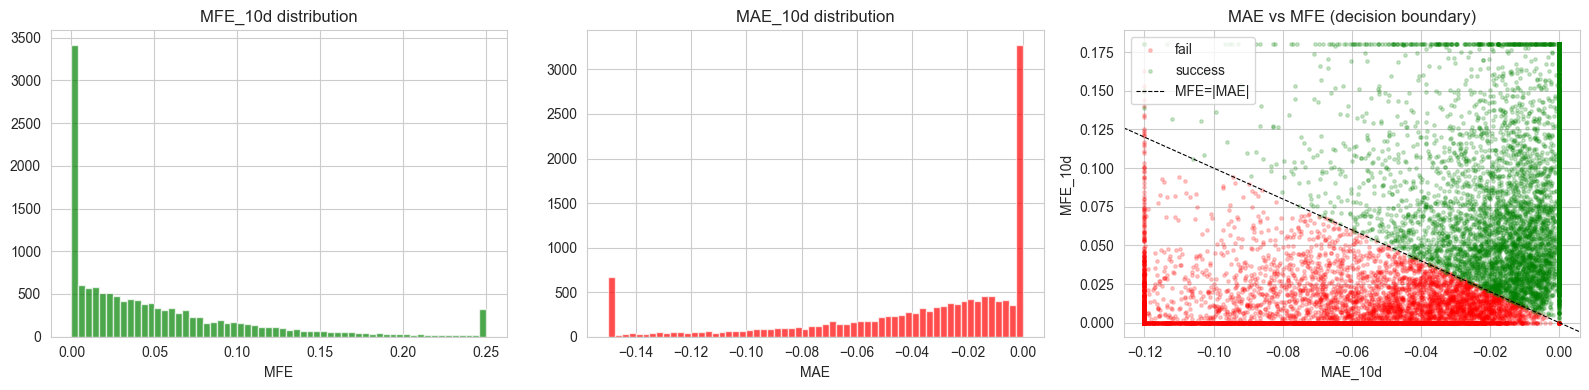

In [4]:
training_df['Y_breakout'] = (
    training_df['mfe_10d'] > training_df['mae_10d'].abs()
).astype(int)

base_rate = training_df['Y_breakout'].mean()
print(f'Breakout success rate (MFE_10d > |MAE_10d|): {base_rate:.2%}')
print(f'001 win rate (net_return > threshold)       : {training_df["Y"].mean():.2%}')

ct = pd.crosstab(
    training_df['Y'], training_df['Y_breakout'],
    rownames=['001 label (Y)'], colnames=['003 label (Y_breakout)'],
    normalize='index',
)
print('\nLabel agreement (row=001, col=003):')
print(ct.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(training_df['mfe_10d'].clip(0, 0.25), bins=60, color='green', alpha=0.7)
axes[0].set_title('MFE_10d distribution'); axes[0].set_xlabel('MFE')

axes[1].hist(training_df['mae_10d'].clip(-0.15, 0), bins=60, color='red', alpha=0.7)
axes[1].set_title('MAE_10d distribution'); axes[1].set_xlabel('MAE')

for label, color in [(0, 'red'), (1, 'green')]:
    m = training_df['Y_breakout'] == label
    axes[2].scatter(
        training_df.loc[m, 'mae_10d'].clip(-0.12, 0),
        training_df.loc[m, 'mfe_10d'].clip(0, 0.18),
        alpha=0.2, s=6, color=color,
        label='success' if label else 'fail',
    )
axes[2].axline((0, 0), slope=-1, color='black', lw=0.8, ls='--', label='MFE=|MAE|')
axes[2].set_xlabel('MAE_10d'); axes[2].set_ylabel('MFE_10d')
axes[2].set_title('MAE vs MFE (decision boundary)'); axes[2].legend()

plt.tight_layout(); plt.show()

# 5. Chronological Train / Test Split

Identical to `train_models_001` — no shuffle, 10-day embargo gap.

In [5]:
TRAIN_END_DATE = '2022-06-30'
EMBARGO_DAYS   = 10

train_mask  = training_df['entry_date'] <= pd.Timestamp(TRAIN_END_DATE)
embargo_end = pd.Timestamp(TRAIN_END_DATE) + pd.Timedelta(days=EMBARGO_DAYS)
test_mask   = training_df['entry_date'] > embargo_end

X_train = training_df.loc[train_mask, feature_columns].copy()
y_train = training_df.loc[train_mask, 'Y_breakout'].copy()
X_test  = training_df.loc[test_mask,  feature_columns].copy()
y_test  = training_df.loc[test_mask,  'Y_breakout'].copy()

returns_test     = training_df.loc[test_mask, 'net_return'].copy()
dates_train      = training_df.loc[train_mask, 'entry_date'].copy()
exit_dates_train = training_df.loc[train_mask, 'exit_date'].copy()
dates_test       = training_df.loc[test_mask,  'entry_date'].copy()

print(f'Train : {dates_train.min().date()} → {dates_train.max().date()} ({len(X_train):,} trades)')
print(f'Embargo: {pd.Timestamp(TRAIN_END_DATE).date()} → {embargo_end.date()}')
print(f'Test  : {dates_test.min().date()} → {dates_test.max().date()} ({len(X_test):,} trades)')
print(f'\nTrain label balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test label balance : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train : 2017-05-22 → 2022-06-30 (7,780 trades)
Embargo: 2022-06-30 → 2022-07-10
Test  : 2022-07-12 → 2026-04-06 (6,121 trades)

Train label balance: {1: 0.535, 0: 0.465}
Test label balance : {1: 0.524, 0: 0.476}


# 6. Feature Scaling + Sample Weights

In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index,
)


def compute_sample_uniqueness(
    entry_dates: pd.Series, exit_dates: pd.Series
) -> np.ndarray:
    """López de Prado uniqueness weights for overlapping holding periods."""
    n = len(entry_dates)
    entries = entry_dates.values
    exits   = exit_dates.values
    overlaps = np.array([
        ((entries <= exits[i]) & (exits >= entries[i])).sum()
        for i in range(n)
    ], dtype=float)
    w = 1.0 / np.maximum(overlaps, 1)
    return w / w.mean()


train_weights = compute_sample_uniqueness(
    dates_train.reset_index(drop=True),
    exit_dates_train.reset_index(drop=True),
)
print(f'Weights — min:{train_weights.min():.3f}  '
      f'median:{np.median(train_weights):.3f}  max:{train_weights.max():.3f}')
print(f'Effective sample size: '
      f'{(train_weights.sum())**2 / (train_weights**2).sum():.0f} / {len(train_weights)}')

Weights — min:0.042  median:0.951  max:7.045
Effective sample size: 6470 / 7780


# 7. Purged & Embargoed K-Fold CV

In [7]:
class PurgedKFold:
    """Purged & embargoed k-fold (AFML Ch.7) — identical to train_models_001."""

    def __init__(self, n_splits=5, entry_dates=None, exit_dates=None, embargo_pct=0.01):
        self.n_splits    = n_splits
        self.entry_dates = entry_dates.reset_index(drop=True)
        self.exit_dates  = exit_dates.reset_index(drop=True)
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n          = len(X)
        indices    = np.arange(n)
        embargo_n  = int(n * self.embargo_pct)
        test_ranges = np.array_split(indices, self.n_splits)

        for test_idx in test_ranges:
            test_start_t = self.entry_dates.iloc[test_idx[0]]
            test_end_t   = self.exit_dates.iloc[test_idx[-1]]

            train_mask = np.ones(n, dtype=bool)
            train_mask[test_idx] = False

            for i in indices[train_mask]:
                if (self.entry_dates.iloc[i] <= test_end_t) and \
                   (self.exit_dates.iloc[i]  >= test_start_t):
                    train_mask[i] = False

            embargo_end_idx = min(test_idx[-1] + 1 + embargo_n, n)
            train_mask[test_idx[-1] + 1 : embargo_end_idx] = False
            yield indices[train_mask], test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


purged_cv = PurgedKFold(
    n_splits=5,
    entry_dates=dates_train,
    exit_dates=exit_dates_train,
    embargo_pct=0.01,
)
print('PurgedKFold ready')

PurgedKFold ready


# 8. Lorentzian KNN Classifier

Distance: $d(x, y) = \sum_i \ln(1 + |x_i - y_i|)$

- A 10× feature spike → only 3.4× distance — outlier robust
- `temporal_step > 1` forces temporal diversity (TradingView style)
- sklearn-compatible → plugs into `CalibratedClassifierCV`
- `P(success)` = sample-weighted fraction of K neighbors with `Y_breakout = 1`

In [8]:
class LorentzianKNNClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self, n_neighbors: int = 20, temporal_step: int = 1):
        self.n_neighbors   = n_neighbors
        self.temporal_step = temporal_step

    def fit(self, X, y, sample_weight=None) -> 'LorentzianKNNClassifier':
        self.classes_  = np.array([0, 1])
        self.X_train_  = np.asarray(X, dtype=np.float64)
        self.y_train_  = np.asarray(y, dtype=np.float64)
        self.w_train_  = (
            np.asarray(sample_weight, dtype=np.float64)
            if sample_weight is not None
            else np.ones(len(y), dtype=np.float64)
        )
        return self

    def _predict_single(self, x: np.ndarray) -> float:
        dist = np.sum(np.log1p(np.abs(self.X_train_ - x)), axis=1)

        if self.temporal_step > 1:
            mask = np.zeros(len(dist), dtype=bool)
            mask[:: self.temporal_step] = True
            dist = np.where(mask, dist, np.inf)

        valid_n = int((dist < np.inf).sum())
        k = min(self.n_neighbors, valid_n)
        if k == 0:
            return 0.5

        idx = np.argpartition(dist, k - 1)[:k]
        idx = idx[dist[idx] < np.inf]

        w = self.w_train_[idx]
        w = w / w.sum()
        return float(np.dot(w, self.y_train_[idx]))

    def predict_proba(self, X) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        p = np.array([self._predict_single(x) for x in X])
        return np.column_stack([1 - p, p])

    def predict(self, X) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


print('LorentzianKNNClassifier defined')

LorentzianKNNClassifier defined


# 9. Hyperparameter Search — Purged CV

In [9]:
X_tr = X_train_scaled.values
y_tr = y_train.values


def _rows(arr, idx):
    return arr.iloc[idx] if hasattr(arr, 'iloc') else arr[idx]


candidate_k    = [5, 10, 20, 30, 50]
candidate_step = [1, 2, 4]

results = []
total   = len(candidate_k) * len(candidate_step)
done    = 0

for k in candidate_k:
    for step in candidate_step:
        fold_aucs = []
        for tr_idx, val_idx in purged_cv.split(X_train_scaled):
            m = LorentzianKNNClassifier(n_neighbors=k, temporal_step=step)
            m.fit(
                _rows(X_tr, tr_idx), _rows(y_tr, tr_idx),
                sample_weight=train_weights[tr_idx],
            )
            proba = m.predict_proba(_rows(X_tr, val_idx))[:, 1]
            fold_aucs.append(roc_auc_score(_rows(y_tr, val_idx), proba))

        mean_auc = float(np.mean(fold_aucs))
        results.append({'k': k, 'step': step, 'cv_auc': mean_auc})
        done += 1
        print(f'[{done:2d}/{total}]  k={k:2d}  step={step}  '
              f'cv_auc={mean_auc:.4f}  folds={[round(v,3) for v in fold_aucs]}')

cv_results = pd.DataFrame(results).sort_values('cv_auc', ascending=False)
print('\n=== Top 5 configs ===')
print(cv_results.head(5).to_string(index=False))

[ 1/15]  k= 5  step=1  cv_auc=0.5156  folds=[0.528, 0.545, 0.505, 0.499, 0.501]
[ 2/15]  k= 5  step=2  cv_auc=0.5220  folds=[0.514, 0.542, 0.528, 0.505, 0.52]
[ 3/15]  k= 5  step=4  cv_auc=0.5327  folds=[0.522, 0.54, 0.542, 0.503, 0.557]
[ 4/15]  k=10  step=1  cv_auc=0.5272  folds=[0.529, 0.538, 0.54, 0.513, 0.516]
[ 5/15]  k=10  step=2  cv_auc=0.5224  folds=[0.508, 0.533, 0.536, 0.5, 0.534]
[ 6/15]  k=10  step=4  cv_auc=0.5261  folds=[0.502, 0.54, 0.531, 0.494, 0.564]
[ 7/15]  k=20  step=1  cv_auc=0.5309  folds=[0.537, 0.525, 0.554, 0.5, 0.54]
[ 8/15]  k=20  step=2  cv_auc=0.5260  folds=[0.502, 0.525, 0.555, 0.501, 0.547]
[ 9/15]  k=20  step=4  cv_auc=0.5183  folds=[0.491, 0.529, 0.517, 0.496, 0.559]
[10/15]  k=30  step=1  cv_auc=0.5300  folds=[0.52, 0.525, 0.553, 0.505, 0.546]
[11/15]  k=30  step=2  cv_auc=0.5218  folds=[0.502, 0.521, 0.536, 0.502, 0.549]
[12/15]  k=30  step=4  cv_auc=0.5178  folds=[0.493, 0.521, 0.517, 0.496, 0.562]
[13/15]  k=50  step=1  cv_auc=0.5283  folds=[0.518

# 10. Train Final Lorentzian KNN + Calibrate

In [ ]:
best_row  = cv_results.iloc[0]
BEST_K    = int(best_row['k'])
BEST_STEP = int(best_row['step'])
print(f'Best config: k={BEST_K}  temporal_step={BEST_STEP}  cv_auc={best_row["cv_auc"]:.4f}')

# Chronological 80/20 split within train for isotonic calibration
_cal_cut  = int(len(X_train_scaled) * 0.80)
X_knn_fit = X_train_scaled.iloc[:_cal_cut]
y_knn_fit = y_train.iloc[:_cal_cut]
w_knn_fit = train_weights[:_cal_cut]
X_cal     = X_train_scaled.iloc[_cal_cut:]
y_cal     = y_train.iloc[_cal_cut:]

base_knn = LorentzianKNNClassifier(n_neighbors=BEST_K, temporal_step=BEST_STEP)
base_knn.fit(X_knn_fit.values, y_knn_fit.values, sample_weight=w_knn_fit)

# Manual isotonic calibration — avoids cv='prefit' which was removed in newer sklearn
raw_cal_proba = base_knn.predict_proba(X_cal.values)[:, 1]
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(raw_cal_proba, y_cal.values)


class _CalibratedKNN:
    """Thin wrapper: base KNN → isotonic calibration."""
    def __init__(self, knn, iso):
        self._knn = knn
        self._iso = iso

    def predict_proba(self, X):
        raw = self._knn.predict_proba(np.asarray(X))[:, 1]
        cal = self._iso.predict(raw)
        return np.column_stack([1 - cal, cal])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


calibrated_knn = _CalibratedKNN(base_knn, iso_reg)
print('Calibrated KNN trained (isotonic regression on held-out 20% of train).')

# 11. Evaluation Helpers

In [ ]:
def evaluate_model(
    y_true,
    y_proba: np.ndarray,
    returns: pd.Series,
    threshold: float = 0.55,
) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    take   = y_pred == 1

    def sharpe(r):
        return r.mean() / (r.std() + 1e-9) * np.sqrt(252) if len(r) > 1 else 0.0

    m = {
        'auc':           roc_auc_score(y_true, y_proba),
        'brier':         brier_score_loss(y_true, y_proba),
        'precision':     precision_score(y_true, y_pred, zero_division=0),
        'recall':        recall_score(y_true, y_pred, zero_division=0),
        'f1':            f1_score(y_true, y_pred, zero_division=0),
        'trades_taken':  int(take.sum()),
        'pct_filtered':  float((~take).mean()),
        'base_mean_ret': float(returns.mean()),
        'filt_mean_ret': float(returns[take].mean()) if take.sum() else 0.0,
        'base_sharpe':   sharpe(returns),
        'filt_sharpe':   sharpe(returns[take]) if take.sum() > 1 else 0.0,
    }
    m['sharpe_lift'] = m['filt_sharpe'] - m['base_sharpe']
    return m


def plot_evaluation(name, y_true, y_proba, returns, threshold=0.55):
    m    = evaluate_model(y_true, y_proba, returns, threshold)
    pred = (y_proba >= threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Fail', 'Pred Win'],
                yticklabels=['Actual Fail', 'Actual Win'])
    axes[0].set_title(f'{name}\nConfusion (thr={threshold})')

    axes[1].hist(y_proba[np.asarray(y_true) == 0], bins=30, alpha=0.5, label='Fail', color='red')
    axes[1].hist(y_proba[np.asarray(y_true) == 1], bins=30, alpha=0.5, label='Win',  color='green')
    axes[1].axvline(threshold, color='black', ls='--', label=f'thr={threshold}')
    axes[1].set_xlabel('P(breakout success)'); axes[1].legend()
    axes[1].set_title('Probability Distribution')

    take = pred == 1
    axes[2].plot(np.cumsum(returns.values),          color='gray',      label='All trades')
    axes[2].plot(np.cumsum(returns.values * take),   color='steelblue', label=f'KNN filtered (thr={threshold})')
    axes[2].set_title('Cumulative return'); axes[2].set_xlabel('Trade #')
    axes[2].legend()

    plt.suptitle(
        f'AUC={m["auc"]:.3f}  precision={m["precision"]:.3f}  Sharpe lift={m["sharpe_lift"]:+.3f}',
        y=1.02,
    )
    plt.tight_layout(); plt.show()
    return m


print('Evaluation helpers ready')

# 12. Test Set Evaluation

In [ ]:
print('Predicting on test set …')
y_proba_test = calibrated_knn.predict_proba(X_test_scaled)[:, 1]

metrics = plot_evaluation(
    f'Lorentzian KNN (k={BEST_K}, step={BEST_STEP})',
    y_test.values, y_proba_test, returns_test,
    threshold=0.55,
)

print('\n=== Lorentzian KNN Test Metrics ===')
for key, val in metrics.items():
    print(f'  {key:18s}: {val:.4f}' if isinstance(val, float) else f'  {key:18s}: {val}')

# 13. Probability Threshold Sweep

In [ ]:
thresholds = np.arange(0.40, 0.75, 0.02)
sweep_rows = []
for thr in thresholds:
    m = evaluate_model(y_test.values, y_proba_test, returns_test, threshold=thr)
    m['threshold'] = thr
    sweep_rows.append(m)
sweep = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(sweep['threshold'], sweep['filt_sharpe'], marker='o', ms=4, color='steelblue')
axes[0].axhline(metrics['base_sharpe'], color='gray', ls='--', label='No filter')
axes[0].set_title('Filtered Sharpe vs Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Annualized Sharpe'); axes[0].legend()

axes[1].plot(sweep['threshold'], sweep['precision'], marker='o', ms=4, color='green')
axes[1].set_title('Precision vs Threshold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Precision')

axes[2].plot(sweep['threshold'], sweep['trades_taken'], marker='o', ms=4, color='orange')
axes[2].set_title('Trades Taken vs Threshold')
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('# Trades')

plt.tight_layout(); plt.show()

best_thr_row = sweep.loc[sweep['filt_sharpe'].idxmax()]
BEST_THRESHOLD = float(best_thr_row['threshold'])
print(f'Optimal threshold (max Sharpe): {BEST_THRESHOLD:.2f}')
print(f'  filt_sharpe  = {best_thr_row["filt_sharpe"]:.3f}')
print(f'  sharpe_lift  = {best_thr_row["sharpe_lift"]:+.3f}')
print(f'  precision    = {best_thr_row["precision"]:.3f}')
print(f'  trades_taken = {int(best_thr_row["trades_taken"])}')

# 14. Calibration Curve

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
frac_pos, mean_pred = calibration_curve(
    y_test.values, y_proba_test, n_bins=10, strategy='quantile'
)
ax.plot(mean_pred, frac_pos, marker='o', label=f'Lorentzian KNN (k={BEST_K})')
ax.set_xlabel('Mean predicted P(success)')
ax.set_ylabel('Empirical fraction of successes')
ax.set_title('Calibration Curve — Breakout Success (10-day MAE/MFE label)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 15. Baseline Comparison

| Baseline | Description |
|---|---|
| Naive | Always predict base rate — no filter |
| Random | Predict U(0,1) — random filter |
| 001 trade label | Use original net-return win/loss as breakout predictor |

In [ ]:
rng = np.random.default_rng(42)
y_naive  = np.full(len(y_test), base_rate)
y_random = rng.uniform(0, 1, len(y_test))
y_001    = training_df.loc[test_mask, 'Y'].values.astype(float)

comparison_rows = []
for name, proba in [
    ('Lorentzian KNN',    y_proba_test),
    ('Naive (base rate)', y_naive),
    ('Random',            y_random),
    ('001 trade label',   y_001),
]:
    try:
        m = evaluate_model(y_test.values, proba, returns_test, threshold=BEST_THRESHOLD)
    except Exception:
        m = dict.fromkeys(
            ['auc','precision','recall','filt_sharpe','sharpe_lift','trades_taken','pct_filtered'],
            np.nan,
        )
    m['model'] = name
    comparison_rows.append(m)

cmp_df = pd.DataFrame(comparison_rows).set_index('model')
display_cols = ['auc', 'precision', 'recall', 'filt_sharpe', 'sharpe_lift', 'trades_taken', 'pct_filtered']
print('=== Baseline Comparison ===')
print(cmp_df[display_cols].round(4))

# 16. Permutation Feature Importance

Permute each feature, measure AUC drop. Higher drop = more critical to distance structure.

In [ ]:
base_auc  = roc_auc_score(y_test.values, y_proba_test)
X_test_np = X_test_scaled.values.copy()

print(f'Base AUC: {base_auc:.4f}  — running permutation importance …')
perm_importance = {}

for i, feat in enumerate(feature_columns):
    X_perm = X_test_np.copy()
    X_perm[:, i] = rng.permutation(X_perm[:, i])
    p_perm = calibrated_knn.predict_proba(X_perm)[:, 1]
    perm_importance[feat] = base_auc - roc_auc_score(y_test.values, p_perm)

perm_series = pd.Series(perm_importance).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
perm_series.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.axvline(0, color='black', lw=0.8)
plt.title(f'Permutation Feature Importance — Lorentzian KNN (k={BEST_K})')
plt.xlabel('AUC drop when feature permuted')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print('\nTop 10 features:')
print(perm_series.head(10).round(4))

# 17. Save Model Artifacts

In [ ]:
os.makedirs('../models', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')

joblib.dump(calibrated_knn, f'../models/lorentzian_knn_breakout_{ts}.joblib')
joblib.dump(scaler,         f'../models/scaler_breakout_{ts}.joblib')

meta = {
    'notebook':         'train_models_003',
    'n_neighbors':      BEST_K,
    'temporal_step':    BEST_STEP,
    'best_threshold':   BEST_THRESHOLD,
    'cv_auc':           float(best_row['cv_auc']),
    'test_auc':         float(base_auc),
    'test_sharpe_lift': float(best_thr_row['sharpe_lift']),
    'label':            'Y_breakout: MFE_10d > |MAE_10d|',
    'window_days':      WINDOW_DAYS,
    'train_end':        TRAIN_END_DATE,
    'features':         feature_columns,
    'timestamp':        ts,
}
with open(f'../models/lorentzian_knn_breakout_meta_{ts}.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Artifacts saved (ts={ts})')
for k, v in meta.items():
    if k != 'features':
        print(f'  {k}: {v}')

# 📋 Summary

## Validation question
> *Does Lorentzian KNN successfully predict whether a breakout entry holds for 10 days?*

## Label
| Label | Condition | Interpretation |
|-------|-----------|----------------|
| `Y_breakout = 1` | `MFE_10d > \|MAE_10d\|` | Favorable 10d excursion > adverse — breakout held |
| `Y_breakout = 0` | otherwise | Price reversed harder than it moved in your favor |

## Architecture (forked from 001)
| Component | Detail |
|-----------|--------|
| Features | Same 55 features as `train_models_001` |
| Split | Chronological, `TRAIN_END=2022-06-30`, embargo=10d |
| CV | Purged & Embargoed K-Fold (5 splits) |
| Sample weights | López de Prado uniqueness |
| Distance | Lorentzian `Σ log(1+\|Δ\|)` |
| Calibration | Isotonic on held-out 20% of train |

## Honest expectations
- **AUC 0.52–0.58** is realistic for this task on VN equities
- **Sharpe lift 0.1–0.3** is a good outcome at optimal threshold
- If AUC > 0.65 → audit for data leakage
- If AUC ≈ 0.50 → KNN alone insufficient; combine with regime filter from `regime_detection_003.ipynb`

## Next steps
1. **Regime-conditioned KNN** — restrict neighbor search to the same market regime (HDBSCAN clusters)
2. **Ensemble with 001** — `P(take) = P_001(win) × P_003(breakout_success)` combined signal
3. **Walk-forward re-validation** — quarterly retrain windows
4. **Feature subset** — use only top-10 permutation-important features to reduce KNN dimensionality